In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv("train.csv")

In [85]:
df.shape

(1460, 81)

In [86]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [87]:
df = df.drop(columns=["Alley", "MasVnrType", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"])

In [88]:
df = df.drop(columns=["Id"])

In [89]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage     259
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

In [90]:
naNum = df.loc[:, df.isnull().sum() > 0].select_dtypes(include="number").columns
naNum

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='object')

<Axes: xlabel='LotFrontage', ylabel='Count'>

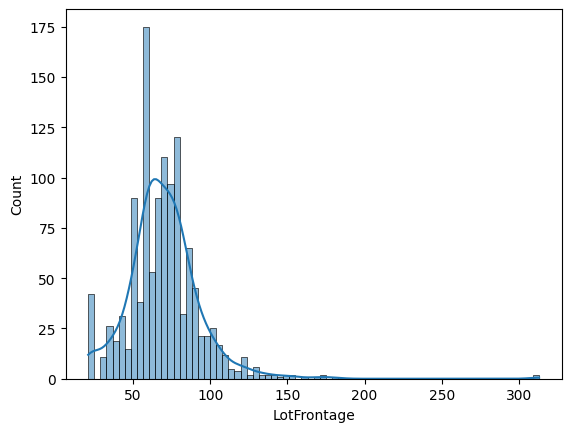

In [91]:
sns.histplot(df["LotFrontage"], kde=True)

<Axes: xlabel='MasVnrArea', ylabel='Count'>

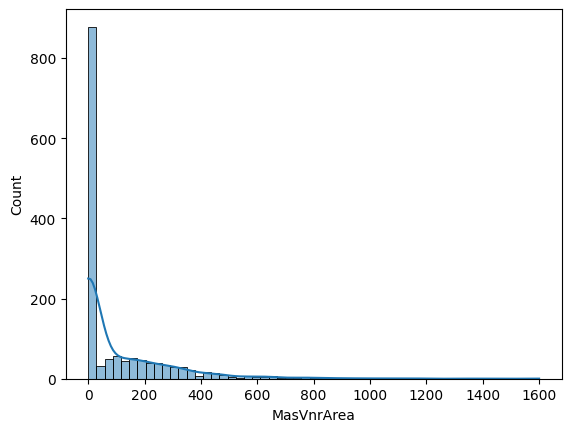

In [92]:
sns.histplot(df["MasVnrArea"], kde=True)

<Axes: xlabel='GarageYrBlt', ylabel='Count'>

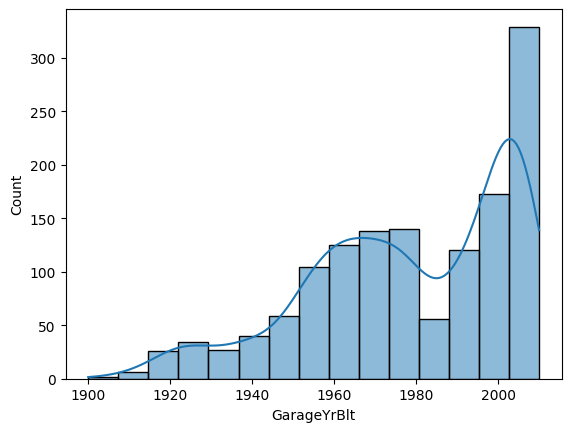

In [93]:
sns.histplot(df["GarageYrBlt"], kde=True)

In [94]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
df[naNum] = num_imputer.fit_transform(df[naNum])

In [95]:
df.isnull().sum()[df.isnull().sum() > 0]

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Electrical       1
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

In [96]:
none_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond"]
df[none_cols] = df[none_cols].fillna("None")
df = df.dropna(subset=["Electrical"])

In [97]:
df.shape

(1459, 74)

In [98]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols.remove("SalePrice")
numeric_cols.remove("MSSubClass")
df["MSSubClass"] = df["MSSubClass"].astype(str)

In [101]:
df[numeric_cols].describe()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,...,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,69.861549,10517.363948,6.100069,5.575737,1971.244003,1984.850583,103.187800,443.943797,46.581220,567.366004,...,473.030158,94.240576,46.692255,21.969157,3.411926,15.071282,2.760795,43.518849,6.322824,2007.815627
std,22.035077,9984.666267,1.383171,1.113079,30.199555,20.644343,180.773158,456.106417,161.369977,441.992392,...,213.869604,125.381679,66.267472,61.137400,29.327247,55.775138,40.191018,496.291826,2.704331,1.328542
min,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,60.000000,7549.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,...,333.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,69.000000,9477.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,384.000000,0.000000,479.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,79.000000,11603.000000,7.000000,6.000000,2000.000000,2004.000000,164.500000,712.500000,0.000000,808.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [103]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [104]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
  transformers=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
  ],
  remainder='passthrough'
)

encoded_array = ct.fit_transform(df)
encoded_df = pd.DataFrame(encoded_array, columns=ct.get_feature_names_out())

In [105]:
encoded_df.head(5)

,onehot__MSSubClass_120,onehot__MSSubClass_160,onehot__MSSubClass_180,onehot__MSSubClass_190,onehot__MSSubClass_20,onehot__MSSubClass_30,onehot__MSSubClass_40,onehot__MSSubClass_45,onehot__MSSubClass_50,onehot__MSSubClass_60,...,remainder__WoodDeckSF,remainder__OpenPorchSF,remainder__EnclosedPorch,remainder__3SsnPorch,remainder__ScreenPorch,remainder__PoolArea,remainder__MiscVal,remainder__MoSold,remainder__YrSold,remainder__SalePrice
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.751887,0.215983,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-1.599030,0.138826,208500.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.625670,-0.704845,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-0.489318,-0.614137,181500.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.751887,-0.070832,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,0.990298,0.138826,223500.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.751887,-0.176501,4.091057,-0.11638,-0.270308,-0.068715,-0.087718,-1.599030,-1.367100,140000.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.779962,0.563180,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,2.100010,0.138826,250000.0


In [106]:
from sklearn.model_selection import train_test_split

X = encoded_df.drop(columns=['remainder__SalePrice'])
y = encoded_df['remainder__SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = model.score(X_train, y_train)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {r2:.4f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

Train R²: 0.9320
Test R²:  0.8765
MSE:  667,125,165.36
RMSE: $25,828.77
